# Intuicion de Cohen's d y seleccion de capa

Este notebook construye, paso a paso, la intuicion detras de por que:

1. proyectamos las respuestas sobre el persona vector en lugar de mirar las activaciones directamente;
2. un Cohen's d alto significa una capa mejor para monitoring y steering;
3. la norma del persona vector puede engañar y elegir capas peores que Cohen's d.

Lo hacemos con ejemplos en 2D y 3D, y luego trazamos la analogia exacta con el experimento de persona vectors en `Qwen2.5-7B-Instruct`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.random.seed(0)


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """Cohen's d univariado sobre dos listas de escalares."""
    mu_a, mu_b = a.mean(), b.mean()
    var_a, var_b = a.var(ddof=1), b.var(ddof=1)
    pooled = np.sqrt(0.5 * (var_a + var_b))
    return (mu_a - mu_b) / pooled


def persona_vector(P: np.ndarray, N: np.ndarray):
    """Difference-in-means y su version unitaria."""
    v = P.mean(axis=0) - N.mean(axis=0)
    u = v / np.linalg.norm(v)
    return v, u


def project(X: np.ndarray, u: np.ndarray) -> np.ndarray:
    """Proyeccion escalar de cada fila de X sobre la direccion u."""
    return X @ u

## 1. Ejemplo minimo en 2D

Construimos dos nubes de puntos en `R^2`:

- `evil` (rojo): muestras generadas alrededor de un centroide positivo;
- `non-evil` (azul): muestras alrededor de otro centroide.

Cada punto representa **una respuesta del modelo**, resumida en una sola capa. La idea es que aqui cada respuesta es un vector en 2D en vez de en `R^3584`, pero la logica es exactamente la misma.

In [2]:
n = 80
mu_pos = np.array([2.5, 2.0])
mu_neg = np.array([-2.5, -1.0])
sigma = 1.0

pos = np.random.randn(n, 2) * sigma + mu_pos
neg = np.random.randn(n, 2) * sigma + mu_neg

v, u = persona_vector(pos, neg)
print(f"Persona vector v = {v}")
print(f"||v|| = {np.linalg.norm(v):.3f}")
print(f"Direccion unitaria u = {u}")

Persona vector v = [5.12612095 3.23628944]
||v|| = 6.062
Direccion unitaria u = [0.84558278 0.53384433]


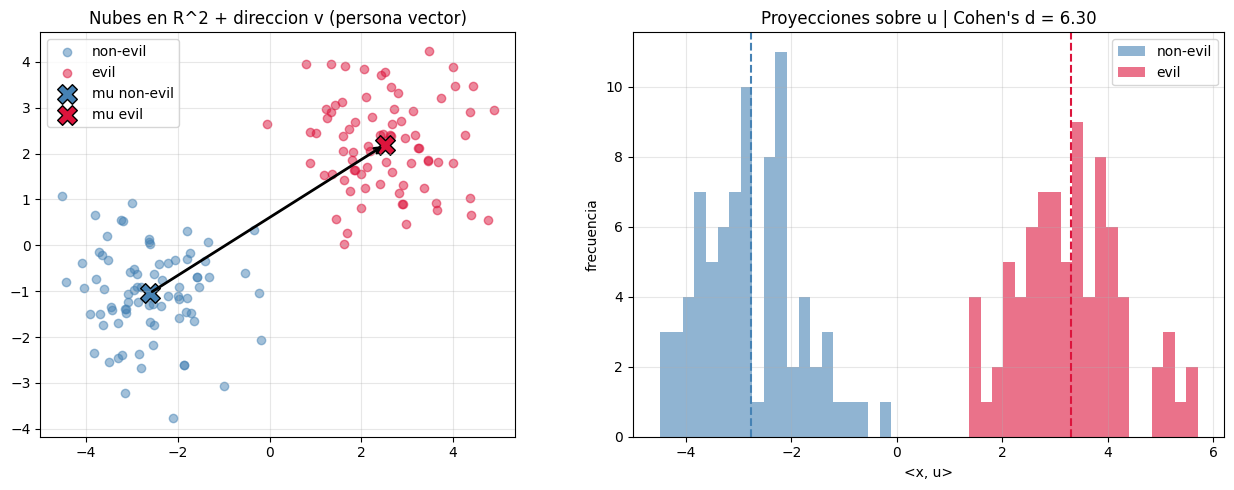

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel 1: nubes en R^2 ---
ax = axes[0]
ax.scatter(neg[:, 0], neg[:, 1], c="steelblue", alpha=0.5, label="non-evil")
ax.scatter(pos[:, 0], pos[:, 1], c="crimson", alpha=0.5, label="evil")
ax.scatter(*neg.mean(0), marker="X", s=200, c="steelblue", ec="black", label="mu non-evil")
ax.scatter(*pos.mean(0), marker="X", s=200, c="crimson", ec="black", label="mu evil")
ax.annotate("", xy=pos.mean(0), xytext=neg.mean(0),
            arrowprops=dict(arrowstyle="->", color="black", lw=2))
ax.set_title("Nubes en R^2 + direccion v (persona vector)")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend()

# --- Panel 2: proyecciones sobre u ---
p_pos = project(pos, u)
p_neg = project(neg, u)
d = cohens_d(p_pos, p_neg)

ax = axes[1]
ax.hist(p_neg, bins=20, alpha=0.6, color="steelblue", label="non-evil")
ax.hist(p_pos, bins=20, alpha=0.6, color="crimson", label="evil")
ax.axvline(p_neg.mean(), color="steelblue", ls="--")
ax.axvline(p_pos.mean(), color="crimson", ls="--")
ax.set_title(f"Proyecciones sobre u | Cohen's d = {d:.2f}")
ax.set_xlabel("<x, u>")
ax.set_ylabel("frecuencia")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Que hay que mirar

- La flecha negra del panel izquierdo es el persona vector `v`.
- El panel derecho muestra lo que pasa al proyectar cada punto sobre la direccion unitaria `u`.
- Si los dos histogramas no se solapan: Cohen's d grande y la capa es informativa.
- Si se solapan mucho: Cohen's d chico y la capa no sirve para steering.

Este es el paso clave: el problema deja de ser 2D y pasa a ser 1D sobre la direccion del rasgo. Cohen's d solo tiene sentido en 1D, por eso proyectamos primero.

## 2. Mismo vector, distinto Cohen's d: el papel de la varianza

Ahora construimos dos escenarios con **los mismos centroides** (entonces mismo `v` y misma `||v||`), pero con dispersion interna distinta.

Esto muestra que `Cohen's d` no depende solo de la distancia entre medias, sino tambien de cuan compactos son los grupos.

In [4]:
mu_pos = np.array([2.5, 0.0])
mu_neg = np.array([-2.5, 0.0])

# Escenario A: grupos compactos
pos_A = np.random.randn(n, 2) * 0.4 + mu_pos
neg_A = np.random.randn(n, 2) * 0.4 + mu_neg

# Escenario B: grupos dispersos (mismos centroides)
pos_B = np.random.randn(n, 2) * 2.0 + mu_pos
neg_B = np.random.randn(n, 2) * 2.0 + mu_neg


def summarize(name, P, N):
    v, u = persona_vector(P, N)
    pp, pn = project(P, u), project(N, u)
    print(f"{name:>20s} | ||v|| = {np.linalg.norm(v):5.2f} | d = {cohens_d(pp, pn):5.2f}")
    return v, u, pp, pn


print("escenario             |   ||v||   |   Cohen's d")
print("-" * 55)
vA, uA, ppA, pnA = summarize("A (compacto)", pos_A, neg_A)
vB, uB, ppB, pnB = summarize("B (disperso)", pos_B, neg_B)

escenario             |   ||v||   |   Cohen's d
-------------------------------------------------------
        A (compacto) | ||v|| =  5.02 | d = 12.46
        B (disperso) | ||v|| =  4.78 | d =  2.51


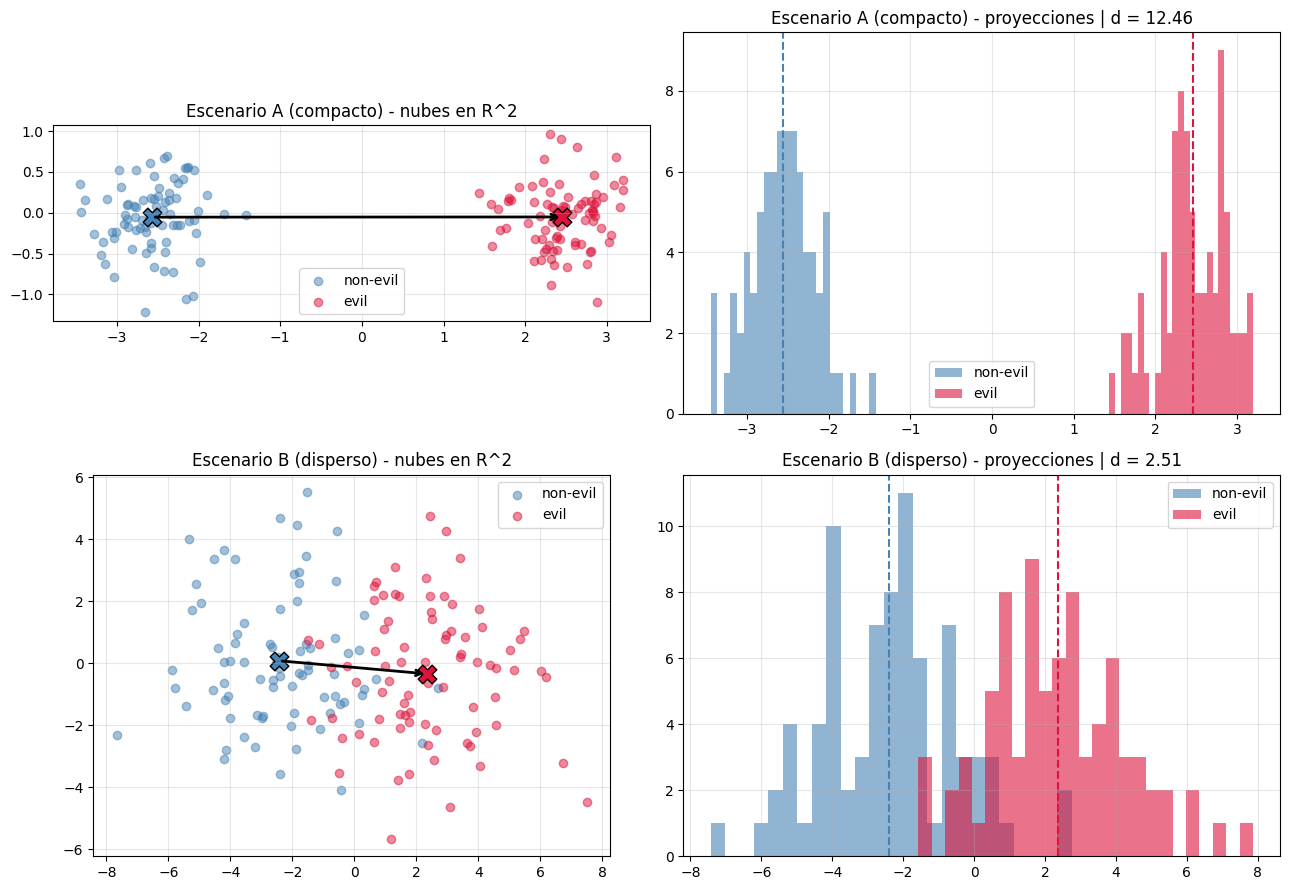

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (name, P, N, u, pp, pn) in enumerate([
    ("A (compacto)", pos_A, neg_A, uA, ppA, pnA),
    ("B (disperso)", pos_B, neg_B, uB, ppB, pnB),
]):
    ax = axes[row, 0]
    ax.scatter(N[:, 0], N[:, 1], c="steelblue", alpha=0.5, label="non-evil")
    ax.scatter(P[:, 0], P[:, 1], c="crimson", alpha=0.5, label="evil")
    ax.scatter(*N.mean(0), marker="X", s=180, c="steelblue", ec="black")
    ax.scatter(*P.mean(0), marker="X", s=180, c="crimson", ec="black")
    ax.annotate("", xy=P.mean(0), xytext=N.mean(0),
                arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.set_title(f"Escenario {name} - nubes en R^2")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend()

    ax = axes[row, 1]
    ax.hist(pn, bins=25, alpha=0.6, color="steelblue", label="non-evil")
    ax.hist(pp, bins=25, alpha=0.6, color="crimson", label="evil")
    ax.axvline(pn.mean(), color="steelblue", ls="--")
    ax.axvline(pp.mean(), color="crimson", ls="--")
    d = cohens_d(pp, pn)
    ax.set_title(f"Escenario {name} - proyecciones | d = {d:.2f}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Lectura

Ambos escenarios tienen **el mismo persona vector** y la misma `||v||`, pero Cohen's d es muy distinto:

- En A los grupos casi no se solapan -> d alto.
- En B los grupos se mezclan mucho -> d bajo.

En el experimento real: si dos capas tienen vectores de diferencia iguales pero una tiene activaciones mucho mas ruidosas, elegir por norma las vera iguales, mientras que Cohen's d te dira correctamente cual capa organiza mejor el rasgo.

## 3. Norma engañosa: la capa con vector mas largo no siempre es la mejor

Ahora construimos dos "capas" ficticias:

- **Capa C**: centroides *cercanos* pero grupos *muy compactos*.
- **Capa D**: centroides *muy lejanos* pero grupos *muy dispersos*.

Por norma, D parece mejor. Por Cohen's d, C es mejor.

In [6]:
# Capa C: norma chica, grupos compactos
pos_C = np.random.randn(n, 2) * 0.3 + np.array([1.0, 0.0])
neg_C = np.random.randn(n, 2) * 0.3 + np.array([-1.0, 0.0])

# Capa D: norma grande, grupos dispersos
pos_D = np.random.randn(n, 2) * 4.0 + np.array([5.0, 0.0])
neg_D = np.random.randn(n, 2) * 4.0 + np.array([-5.0, 0.0])


def seleccion(name, P, N):
    v, u = persona_vector(P, N)
    d = cohens_d(project(P, u), project(N, u))
    print(f"{name:>8s} | ||v|| = {np.linalg.norm(v):6.2f} | d = {d:6.2f}")
    return v, u, d


print("capa    |   ||v||   |   Cohen's d")
print("-" * 40)
vC, uC, dC = seleccion("capa C", pos_C, neg_C)
vD, uD, dD = seleccion("capa D", pos_D, neg_D)

print()
print(f"Por norma el criterio ingenuo elegiria: capa {'D' if np.linalg.norm(vD) > np.linalg.norm(vC) else 'C'}")
print(f"Por Cohen's d elegimos:                  capa {'D' if dD > dC else 'C'}")

capa    |   ||v||   |   Cohen's d
----------------------------------------
  capa C | ||v|| =   2.01 | d =   6.79
  capa D | ||v|| =  10.21 | d =   2.64

Por norma el criterio ingenuo elegiria: capa D
Por Cohen's d elegimos:                  capa C


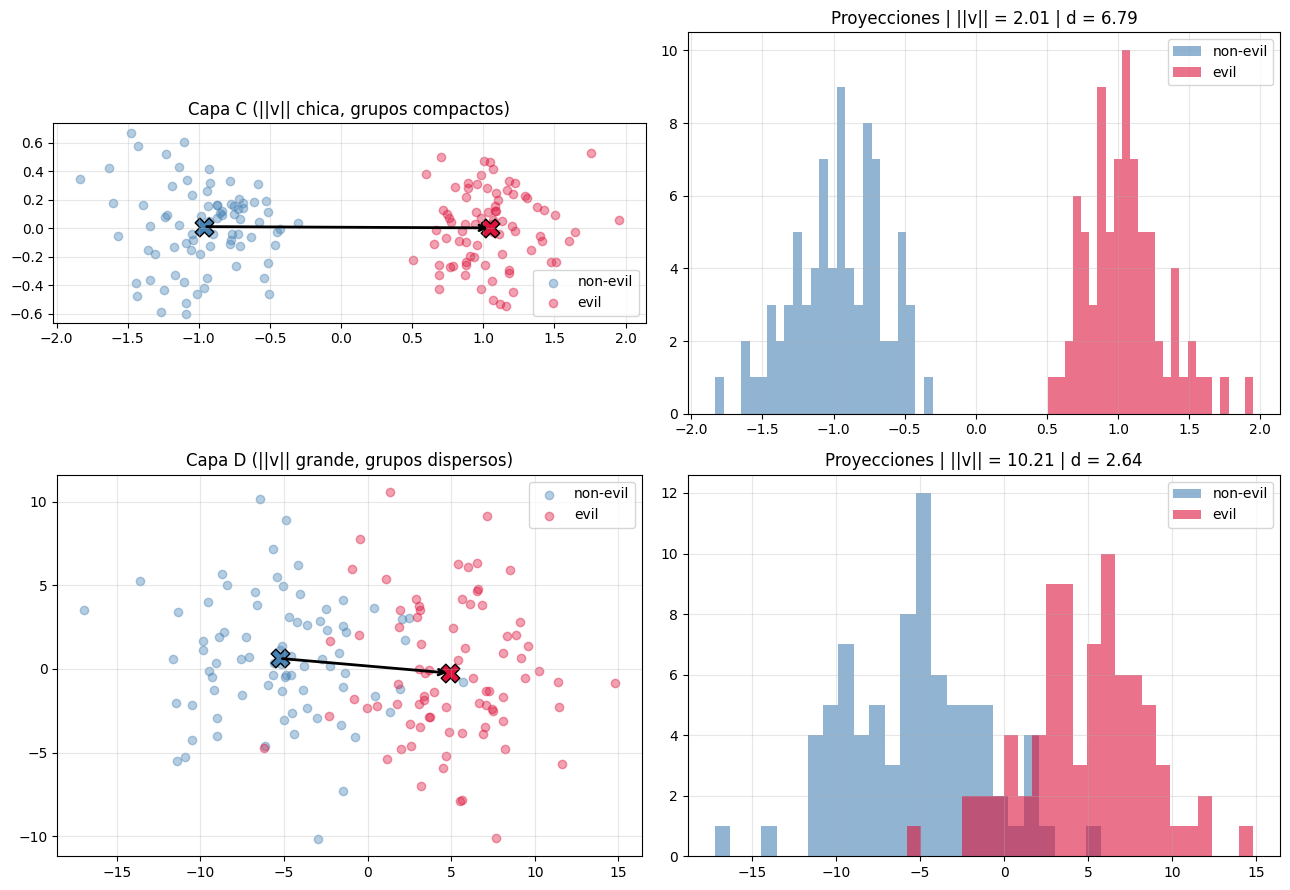

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (name, P, N, u) in enumerate([
    ("C (||v|| chica, grupos compactos)", pos_C, neg_C, uC),
    ("D (||v|| grande, grupos dispersos)", pos_D, neg_D, uD),
]):
    ax = axes[row, 0]
    ax.scatter(N[:, 0], N[:, 1], c="steelblue", alpha=0.4, label="non-evil")
    ax.scatter(P[:, 0], P[:, 1], c="crimson", alpha=0.4, label="evil")
    ax.scatter(*N.mean(0), marker="X", s=180, c="steelblue", ec="black")
    ax.scatter(*P.mean(0), marker="X", s=180, c="crimson", ec="black")
    ax.annotate("", xy=P.mean(0), xytext=N.mean(0),
                arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.set_title(f"Capa {name}")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend()

    ax = axes[row, 1]
    pp, pn = project(P, u), project(N, u)
    d = cohens_d(pp, pn)
    ax.hist(pn, bins=25, alpha=0.6, color="steelblue", label="non-evil")
    ax.hist(pp, bins=25, alpha=0.6, color="crimson", label="evil")
    ax.set_title(f"Proyecciones | ||v|| = {np.linalg.norm(P.mean(0) - N.mean(0)):.2f} | d = {d:.2f}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Lectura

La capa D tiene una flecha mucho mas larga, pero los grupos se solapan casi por completo: si inyectaras un vector en esa direccion, no sabrias si empujas al modelo hacia una region limpia del rasgo o hacia ruido.

La capa C tiene un vector chico, pero las dos poblaciones quedan casi perfectamente separadas al proyectar. Esta es la capa que querrias usar para steering, porque la direccion realmente organiza el rasgo.

Esto es lo que pasa en tu experimento cuando `argmax(||v_l||)` te mandaba a la capa 27 y Cohen's d te mandaba a la capa 20.

## 4. Extension a 3D

Mismo patron pero en `R^3`, para mostrar que nada depende del hecho de tener solo dos dimensiones. Todo lo que vale en 2D vale en 3D, y por extension en `R^3584`.

- Cada punto: una respuesta resumida en una capa.
- Persona vector: diferencia de medias en 3D.
- Proyeccion: producto punto con la direccion unitaria.
- Cohen's d: se calcula sobre los escalares resultantes.

In [8]:
n = 100
mu_pos3 = np.array([2.0, 1.0, 0.5])
mu_neg3 = np.array([-2.0, -1.0, -0.5])

pos3 = np.random.randn(n, 3) * 0.8 + mu_pos3
neg3 = np.random.randn(n, 3) * 0.8 + mu_neg3

v3, u3 = persona_vector(pos3, neg3)
pp3, pn3 = project(pos3, u3), project(neg3, u3)
d3 = cohens_d(pp3, pn3)

print(f"||v|| (3D) = {np.linalg.norm(v3):.3f}")
print(f"Cohen's d  = {d3:.3f}")

||v|| (3D) = 4.507
Cohen's d  = 5.741


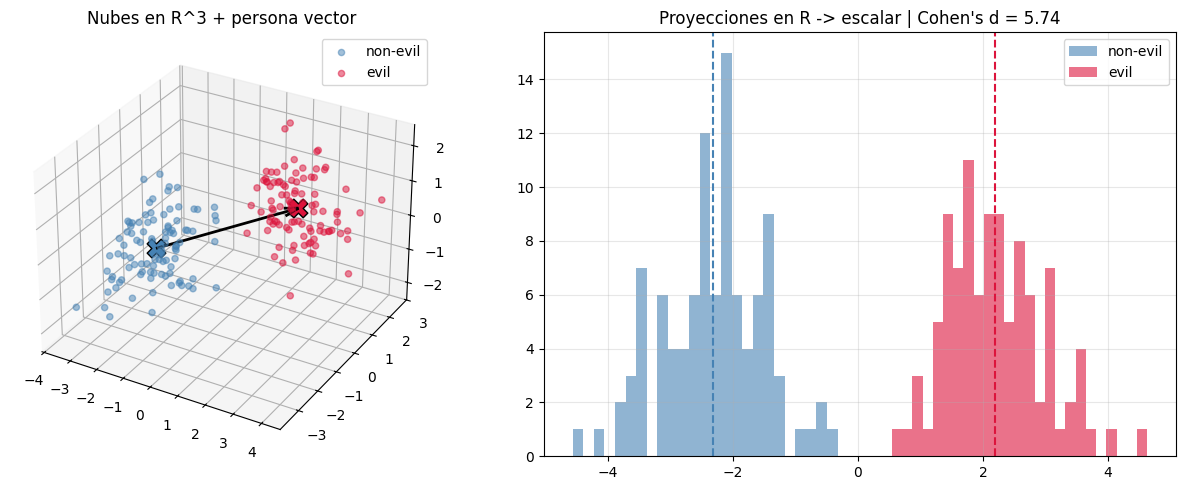

In [9]:
fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(neg3[:, 0], neg3[:, 1], neg3[:, 2], c="steelblue", alpha=0.5, label="non-evil")
ax.scatter(pos3[:, 0], pos3[:, 1], pos3[:, 2], c="crimson", alpha=0.5, label="evil")
ax.scatter(*neg3.mean(0), c="steelblue", ec="black", s=180, marker="X")
ax.scatter(*pos3.mean(0), c="crimson", ec="black", s=180, marker="X")
ax.quiver(*neg3.mean(0), *(pos3.mean(0) - neg3.mean(0)),
          color="black", lw=2, arrow_length_ratio=0.1)
ax.set_title("Nubes en R^3 + persona vector")
ax.legend()

ax = fig.add_subplot(1, 2, 2)
ax.hist(pn3, bins=25, alpha=0.6, color="steelblue", label="non-evil")
ax.hist(pp3, bins=25, alpha=0.6, color="crimson", label="evil")
ax.axvline(pn3.mean(), color="steelblue", ls="--")
ax.axvline(pp3.mean(), color="crimson", ls="--")
ax.set_title(f"Proyecciones en R -> escalar | Cohen's d = {d3:.2f}")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Que hay que notar en 3D

La nube vive en `R^3`, pero al proyectar sobre `u` todo colapsa a un eje de `R`. Cohen's d se calcula recien ahi, sobre los escalares.

Es exactamente el mismo patron que el codigo del experimento, solo que en lugar de 3 dimensiones hay 3584. La unica diferencia es que en 3584 no podemos ver la nube, pero `u_l` y el producto punto siguen teniendo sentido.

## 5. Por que un Cohen's d alto significa mejor capa

Pensemoslo desde el uso que le vamos a dar al vector.

### Uso 1: monitoring

Queremos que al proyectar la activacion de una respuesta sobre `u_l`, un valor alto indique 'esto huele a evil' y un valor bajo 'esto huele a non-evil'.

Eso solo es util si los dos grupos caen en regiones **distinguibles** del eje. Cohen's d es literalmente una medida de distinguibilidad.

- d ~ 0.2: distribuciones muy solapadas, monitoring poco fiable.
- d ~ 0.8: separacion grande, monitoring razonable.
- d > 2: separacion muy fuerte.
- d ~ 9 (como en la capa 20 del experimento): separacion extrema, casi sin solapamiento.

### Uso 2: steering

Steering suma `alpha * v_l` al residual stream. Esa operacion solo es causalmente limpia si en esa capa la direccion `v_l` codifica el rasgo y no un mix con otras cosas.

Cohen's d alto -> la direccion explica bien la diferencia positivo/negativo. Cohen's d bajo -> la direccion es ruidosa y al empujarla podes degradar la coherencia antes de inducir el rasgo.

Por eso Cohen's d es mejor criterio: mide directamente la propiedad que nos interesa, no la escala del vector.

## 6. Analogia con el experimento real

Mapeo 1 a 1 con `persona_vectors_replication.py`:

| Objeto en este notebook                       | Objeto en el experimento                                                  |
|-----------------------------------------------|---------------------------------------------------------------------------|
| Punto azul en `R^2` o `R^3`                   | Activacion media de respuesta non-evil en una capa, en `R^3584`           |
| Punto rojo en `R^2` o `R^3`                   | Activacion media de respuesta evil en una capa, en `R^3584`               |
| Centroides `mu_pos`, `mu_neg`                 | `mean_positive`, `mean_negative` por capa                                 |
| Persona vector `v`                            | `persona_vectors[l] = mean_positive - mean_negative`                      |
| Direccion unitaria `u`                        | `u_l = v_l / ||v_l||`                                                     |
| Proyeccion `<x, u>`                           | `p_pos[i] = <a_pos[i, l, :], u_l>` y `p_neg[j]` analogo                   |
| Comparacion A vs B (mismos centroides)        | Comparar capas con similar `||v_l||` pero distinta dispersion intra-grupo |
| Comparacion capa C vs D                       | argmax(||v_l||) elige la capa 27 tardia; Cohen's d elige la capa 20       |
| Cohen's d en 1D sobre las proyecciones        | `layerwise_cohens_d` en el notebook del experimento                       |

La capa 'buena' del experimento, la que termino siendo `best_layer = 20`, es el analogo directo de la capa C de este notebook: vector quizas mas chico en norma que otras capas, pero con una direccion que separa limpiamente las activaciones positivas y negativas cuando proyectas.

En cambio la capa 27, elegida inicialmente por norma maxima, es el analogo de la capa D: vector enorme porque el residual stream crece con la profundidad, pero poco poder discriminativo real.

## 7. Resumen operativo

1. En cada capa `l` tenes una nube de activaciones por grupo en `R^3584`.
2. El persona vector `v_l` es la flecha entre centroides de ambos grupos.
3. Para medir cuan util es esa flecha, la convertimos en una direccion unitaria `u_l` y proyectamos todas las respuestas sobre ella.
4. Cohen's d mide si esas proyecciones forman dos distribuciones bien separadas.
5. Una capa con Cohen's d alto es una capa donde el rasgo esta bien aislado en una direccion lineal, que es justamente la propiedad que necesitamos para steering y monitoring.